In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
conn = sqlite3.connect('superstore.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

query = """
SELECT 
    "Customer ID",
    "Customer Name",
    "Segment",
    COUNT(DISTINCT "Order ID") as Frequency,
    ROUND(SUM("Sales"), 2) as Monetary,
    MAX("Order Date") as Last_Order_Date
FROM orders
GROUP BY "Customer ID", "Customer Name", "Segment"
ORDER BY Monetary DESC
LIMIT 10
"""

top_customers = pd.read_sql_query(query, conn)
print("Top 10 Customers by Revenue:")
top_customers

Top 10 Customers by Revenue:


,Customer ID,Customer Name,Segment,Frequency,Monetary,Last_Order_Date
0,SM-20320,Sean Miller,Home Office,5,25043.05,8/21/2015
1,TC-20980,Tamara Chand,Corporate,5,19052.22,9/20/2015
2,RB-19360,Raymond Buch,Consumer,6,15117.34,9/25/2017
3,TA-21385,Tom Ashbrook,Home Office,4,14595.62,9/2/2016
4,AB-10105,Adrian Barton,Consumer,10,14473.57,9/25/2016
5,KL-16645,Ken Lonsdale,Consumer,12,14175.23,8/11/2014
6,SC-20095,Sanjit Chand,Consumer,9,14142.33,9/23/2014
7,HL-15040,Hunter Lopez,Consumer,6,12873.30,6/24/2016
8,SE-20110,Sanjit Engle,Consumer,11,12209.44,9/8/2016
9,CC-12370,Christopher Conant,Consumer,5,12129.07,8/15/2016


In [ ]:
import pandas as pd

df['Order Date'] = pd.to_datetime(df['Order Date'])

snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)
print(f"Snapshot Date: {snapshot_date.date()}")

rfm_raw = df.groupby(['Customer ID', 'Customer Name']).agg(
    last_order_date = ('Order Date', 'max'),
    frequency       = ('Order ID',   'nunique'),
    monetary        = ('Sales',      'sum')
).reset_index()

rfm_raw['recency_days'] = (snapshot_date - rfm_raw['last_order_date']).dt.days

rfm_raw['monetary'] = rfm_raw['monetary'].round(2)

rfm_raw = rfm_raw.sort_values('monetary', ascending=False).reset_index(drop=True)

print(f"Total customers: {len(rfm_raw)}")
rfm_raw.head(10)

Snapshot Date: 2017-12-31
Total customers: 793


,Customer ID,Customer Name,last_order_date,frequency,monetary,recency_days
0,SM-20320,Sean Miller,2017-10-12,5,25043.05,80
1,TC-20980,Tamara Chand,2016-11-26,5,19052.22,400
2,RB-19360,Raymond Buch,2017-09-25,6,15117.34,97
3,TA-21385,Tom Ashbrook,2017-10-22,4,14595.62,70
4,AB-10105,Adrian Barton,2017-11-19,10,14473.57,42
5,KL-16645,Ken Lonsdale,2017-11-13,12,14175.23,48
6,SC-20095,Sanjit Chand,2017-01-15,9,14142.33,350
7,HL-15040,Hunter Lopez,2017-11-17,6,12873.30,44
8,SE-20110,Sanjit Engle,2017-12-21,11,12209.44,10
9,CC-12370,Christopher Conant,2017-11-17,5,12129.07,44


In [ ]:
rfm_raw['R_score'] = pd.qcut(rfm_raw['recency_days'], q=5,
                              labels=[5, 4, 3, 2, 1])

rfm_raw['F_score'] = pd.qcut(rfm_raw['frequency'].rank(method='first'), q=5,
                              labels=[1, 2, 3, 4, 5])

rfm_raw['M_score'] = pd.qcut(rfm_raw['monetary'].rank(method='first'), q=5,
                              labels=[1, 2, 3, 4, 5])

rfm_raw[['R_score','F_score','M_score']] = (
    rfm_raw[['R_score','F_score','M_score']].astype(int)
)

rfm_raw['RFM_score'] = rfm_raw['R_score'] + rfm_raw['F_score'] + rfm_raw['M_score']

print(rfm_raw[['Customer Name','recency_days','frequency','monetary',
               'R_score','F_score','M_score','RFM_score']].head(10))

        Customer Name  recency_days  frequency  monetary  R_score  F_score  \
0         Sean Miller            80          5  25043.05        3        2   
1        Tamara Chand           400          5  19052.22        1        2   
2        Raymond Buch            97          6  15117.34        3        3   
3        Tom Ashbrook            70          4  14595.62        3        1   
4       Adrian Barton            42         10  14473.57        4        5   
5        Ken Lonsdale            48         12  14175.23        4        5   
6        Sanjit Chand           350          9  14142.33        1        5   
7        Hunter Lopez            44          6  12873.30        4        3   
8        Sanjit Engle            10         11  12209.44        5        5   
9  Christopher Conant            44          5  12129.07        4        2   

   M_score  RFM_score  
0        5         10  
1        5          8  
2        5         11  
3        5          9  
4        5         14

In [ ]:
def assign_segment(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return "Can't Lose Them"
    elif r <= 2 and f <= 2:
        return 'Lost / Churned'
    elif r >= 3 and f >= 2 and m <= 2:
        return 'Potential Loyalists'
    elif r == 5 and f == 1:
        return 'New Customers'
    else:
        return 'Needs Attention'

rfm_raw['Segment'] = rfm_raw.apply(assign_segment, axis=1)

segment_summary = (rfm_raw
    .groupby('Segment')
    .agg(
        Customers = ('Customer ID', 'count'),
        Avg_Recency = ('recency_days', 'mean'),
        Avg_Frequency = ('frequency', 'mean'),
        Total_Revenue = ('monetary', 'sum')
    )
    .round(1)
    .sort_values('Total_Revenue', ascending=False)
    .reset_index()
)

print(segment_summary.to_string(index=False))

            Segment  Customers  Avg_Recency  Avg_Frequency  Total_Revenue
    Loyal Customers        172         49.1            7.6       648869.8
          Champions         92         25.9            9.7       478518.8
            At Risk         96        221.6            7.9       429572.4
     Lost / Churned        175        371.6            3.7       306110.8
    Needs Attention         88        153.5            5.4       177422.5
   Recent Customers         86         26.5            4.1       164429.9
Potential Loyalists         84         51.2            6.8        92276.6


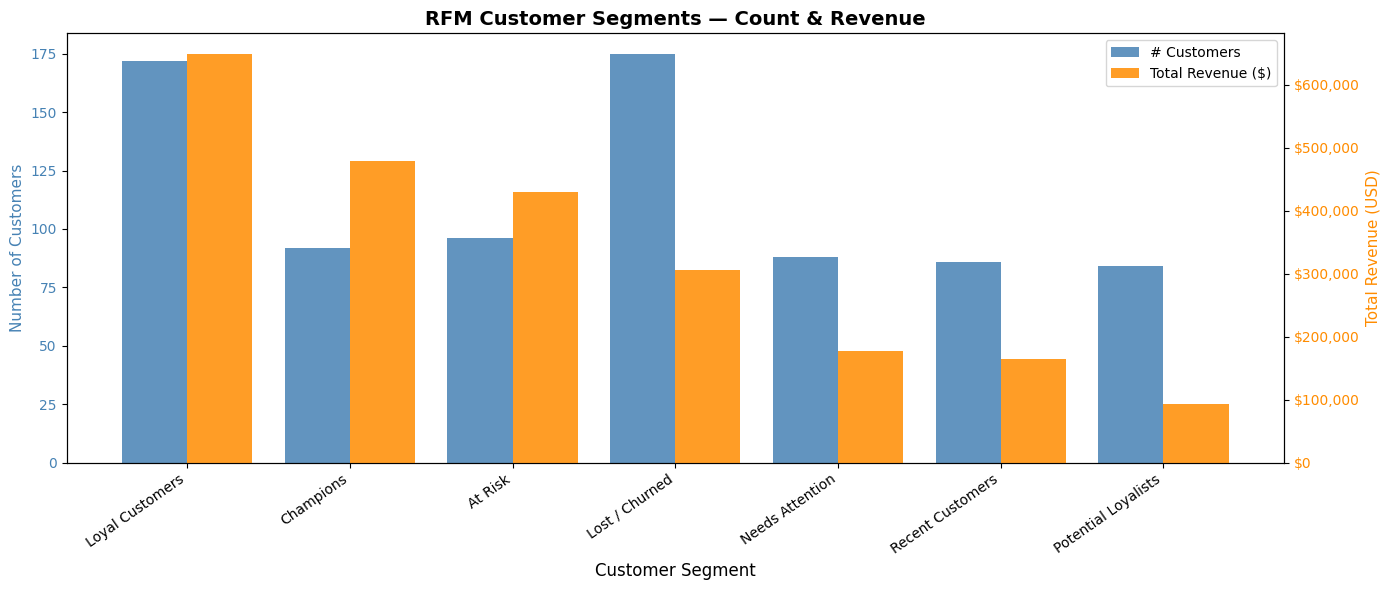

Chart saved → rfm_segments.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

segments  = segment_summary['Segment'].tolist()
customers = segment_summary['Customers'].tolist()
revenue   = segment_summary['Total_Revenue'].tolist()

x     = np.arange(len(segments))
width = 0.4

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2      = ax1.twinx()

ax1.bar(x - width/2, customers, width, label='# Customers',
        color='steelblue', alpha=0.85)
ax2.bar(x + width/2, revenue,   width, label='Total Revenue ($)',
        color='darkorange', alpha=0.85)

ax1.set_xlabel('Customer Segment', fontsize=12)
ax1.set_ylabel('Number of Customers', color='steelblue', fontsize=11)
ax2.set_ylabel('Total Revenue (USD)',  color='darkorange', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'${v:,.0f}'))

ax1.set_xticks(x)
ax1.set_xticklabels(segments, rotation=35, ha='right', fontsize=10)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='darkorange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('RFM Customer Segments — Count & Revenue', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150)
plt.show()
print("Chart saved → rfm_segments.png")